In [5]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine

In [6]:
server = 'DARIELPC'
database = 'FraudAnalyticsDB'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

In [7]:
query = """
SELECT *
FROM transacciones_financieras
"""

df = pd.read_sql(query, engine)

In [8]:
df.head()

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,dispositivo_nuevo,intentos_fallidos,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude
0,1,49,2026-03-31 03:25:00,331758.10,Transferencia,ACH,DOP,República Dominicana,East Linda,119.119.99.54,True,5,9,158342.63,886240.10,False,True,False,False
1,2,315,2025-09-14 08:55:39,750818.86,Retiro,Transferencia Bancaria,DOP,República Dominicana,Cordovamouth,70.127.214.252,False,5,16,432794.73,680492.07,False,False,True,False
2,3,400,2025-07-11 00:03:28,1393581.51,Pago,Tarjeta,DOP,República Dominicana,North Jennifermouth,135.144.10.93,True,2,10,392279.28,442310.53,False,False,False,False
3,4,167,2025-06-29 07:54:40,2972052.48,Pago,Transferencia Bancaria,DOP,República Dominicana,North Elaineshire,179.42.64.18,True,0,17,122161.76,796999.65,False,False,True,False
4,5,241,2026-02-01 05:13:17,3324620.87,Compra,Transferencia Bancaria,DOP,República Dominicana,Stephenport,12.125.69.63,False,2,1,178966.73,55263.63,False,False,False,False


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_transaccion              15000 non-null  int64         
 1   id_cliente                  15000 non-null  int64         
 2   fecha_transaccion           15000 non-null  datetime64[ns]
 3   monto_transaccion           15000 non-null  float64       
 4   tipo_transaccion            15000 non-null  object        
 5   metodo_pago                 15000 non-null  object        
 6   moneda                      15000 non-null  object        
 7   pais_origen                 15000 non-null  object        
 8   ciudad_origen               15000 non-null  object        
 9   ip_dispositivo              15000 non-null  object        
 10  dispositivo_nuevo           15000 non-null  bool          
 11  intentos_fallidos           15000 non-null  int64     

In [8]:
df.isnull().sum()

id_transaccion                0
id_cliente                    0
fecha_transaccion             0
monto_transaccion             0
tipo_transaccion              0
metodo_pago                   0
moneda                        0
pais_origen                   0
ciudad_origen                 0
ip_dispositivo                0
dispositivo_nuevo             0
intentos_fallidos             0
transacciones_24h             0
promedio_historico_cliente    0
desviacion_monto              0
pais_alto_riesgo              0
transaccion_fuera_horario     0
multiples_ips                 0
fraude                        0
dtype: int64

In [11]:
df['fraude'].value_counts(normalize=True) * 100

fraude
False    79.026667
True     20.973333
Name: proportion, dtype: float64

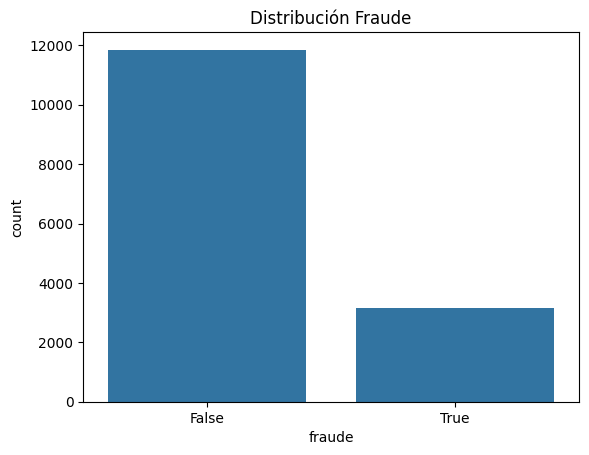

In [10]:
sns.countplot(
    x='fraude',
    data=df
)

plt.title('Distribución Fraude')
plt.show()

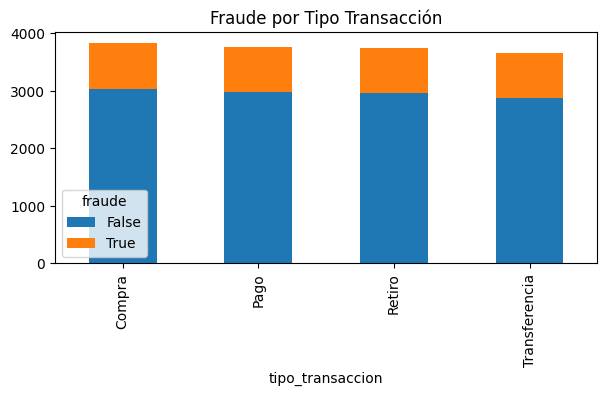

In [ ]:
fraude_tipo = pd.crosstab(
    df['tipo_transaccion'],
    df['fraude']
)
fraude_tipo.plot(
    kind='bar',
    stacked=True,
    figsize=(7,3)
    )
plt.title('Fraude por Tipo Transacción')
plt.show()

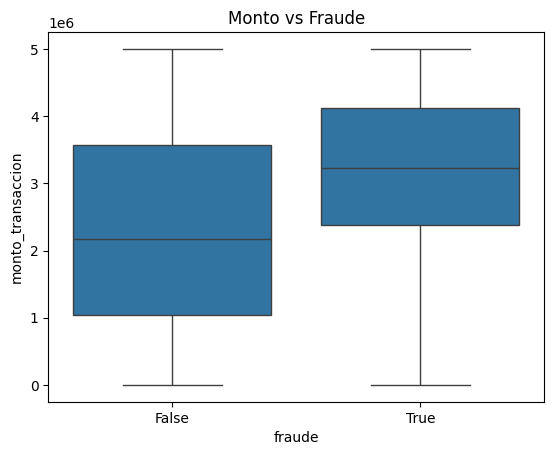

In [16]:
sns.boxplot(
    x='fraude',
    y='monto_transaccion',
    data=df
)

plt.title('Monto vs Fraude')
plt.show()

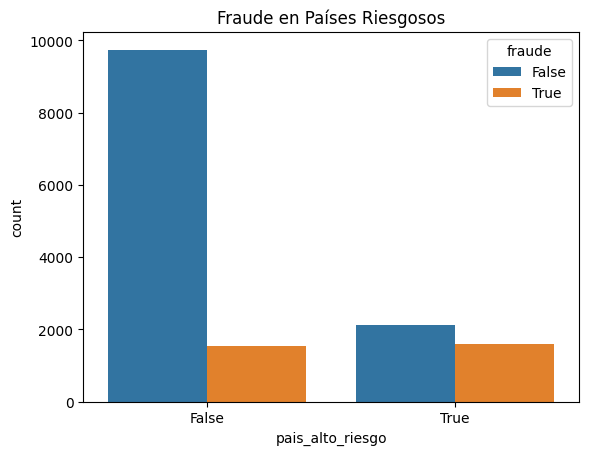

In [17]:
sns.countplot(
    x='pais_alto_riesgo',
    hue='fraude',
    data=df
)

plt.title('Fraude en Países Riesgosos')
plt.show()

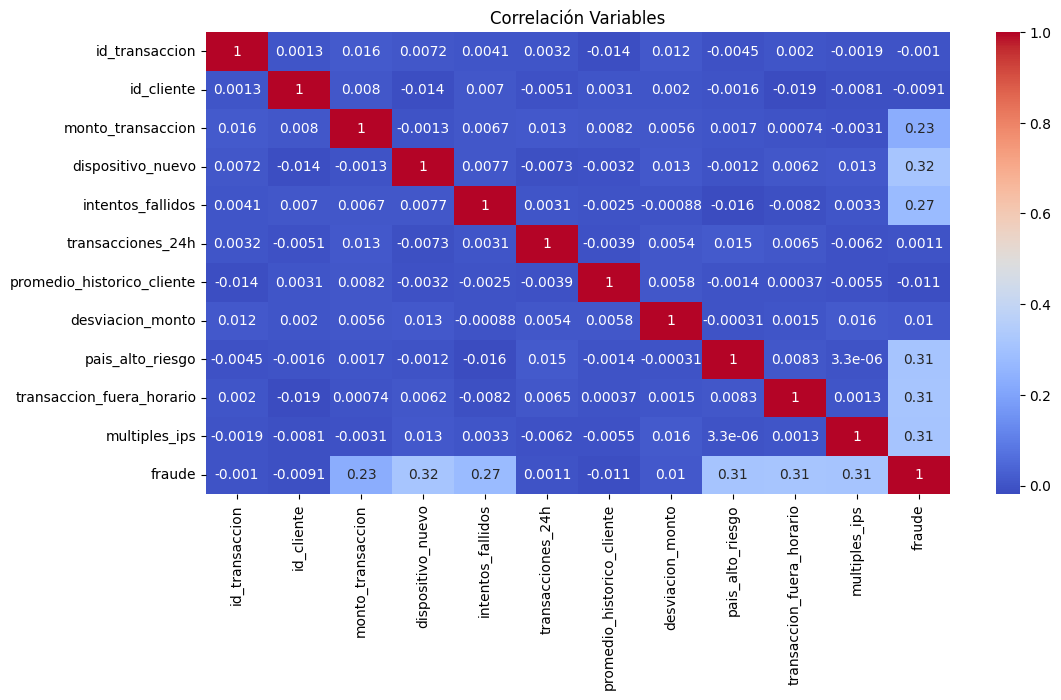

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlación Variables')
plt.show()

In [22]:
# Insight:
# Las transacciones con múltiples intentos
# fallidos presentan mayor riesgo fraude.

In [14]:
df['fraude'].value_counts()

fraude
False    11854
True      3146
Name: count, dtype: int64

In [13]:
df['fraude'].value_counts(normalize=True) * 100

fraude
False    79.026667
True     20.973333
Name: proportion, dtype: float64

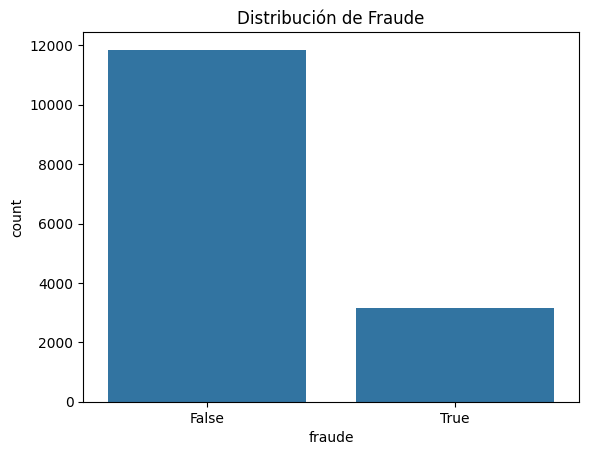

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='fraude',
    data=df
)

plt.title('Distribución de Fraude')
plt.show()